# Potential and Limitation of QELMs

In this notebook I want to reprodue the results of https://arxiv.org/abs/2210.00780.

First of all I want to generate a training dataset, a set of denisty matrices with the corresponding expectation value of chosen observable.

In [1]:
import numpy as np
import qutip as qt
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

#let's define the Pauli matrices
I = np.array([[1, 0],
              [0, 1]], dtype=complex)

X = np.array([[0, 1],
              [1, 0]], dtype=complex)

Y = np.array([[0, -1j],
              [1j,  0]], dtype=complex)

Z = np.array([[1,  0],
              [0, -1]], dtype=complex)

In [2]:
N_tr = 100
N_test = 1000

#density matrices
rho_training = np.zeros((N_tr, 2, 2), dtype=complex)
rho_test = np.zeros((N_test,2,2), dtype=complex)

#expectation values
expe_X_train = np.zeros(N_tr)
expe_X_test = np.zeros(N_test)

In [3]:
for i in range(N_tr):
    #sample a random Bloch vector uniformly in the Bloch ball
    r = np.random.normal(size=3)
    r = r / np.linalg.norm(r) * np.random.rand()**(1/3)
    
    #construct density matrix
    rho_training[i] = 0.5 * (I + r[0]*X + r[1]*Y + r[2]*Z)

    #expectation value of Pauli X
    expe_X_train[i] = np.real(np.trace(rho_training[i] @ X))

for i in range(N_test):
    #sample a random Bloch vector uniformly in the Bloch ball
    r = np.random.normal(size=3)
    r = r / np.linalg.norm(r) * np.random.rand()**(1/3)
    
    #construct density matrix
    rho_test[i] = 0.5 * (I + r[0]*X + r[1]*Y + r[2]*Z)

    #cxpectation value of Pauli X
    expe_X_test[i] = np.real(np.trace(rho_test[i] @ X))


Visualize the states inside the Bloch sphere

In [4]:
def density_to_bloch(rho):
    x = np.real(np.trace(rho @ X))
    y = np.real(np.trace(rho @ Y))
    z = np.real(np.trace(rho @ Z))
    return np.array([x, y, z])

def plot_bloch_sphere(points):
    fig = plt.figure(figsize=(7,7))
    ax = fig.add_subplot(111, projection='3d')

    # Draw sphere surface
    u = np.linspace(0, 2*np.pi, 100)
    v = np.linspace(0, np.pi, 100)
    x = np.outer(np.cos(u), np.sin(v))
    y = np.outer(np.sin(u), np.sin(v))
    z = np.outer(np.ones(np.size(u)), np.cos(v))
    
    ax.plot_surface(x, y, z, color='lightblue', alpha=0.1)

    # Draw axes
    ax.quiver(0,0,0, 1,0,0, color='r')
    ax.quiver(0,0,0, 0,1,0, color='g')
    ax.quiver(0,0,0, 0,0,1, color='b')

    # Plot points
    points = np.array(points)
    ax.scatter(points[:,0], points[:,1], points[:,2], 
               color='black', s=40)

    ax.set_xlim([-1,1])
    ax.set_ylim([-1,1])
    ax.set_zlim([-1,1])
    ax.set_xlabel('X')
    ax.set_ylabel('Y')
    ax.set_zlabel('Z')

    ax.set_box_aspect([1,1,1])
    plt.show()

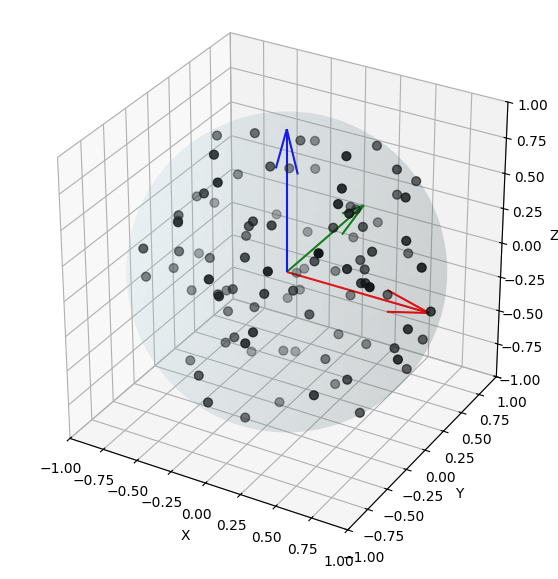

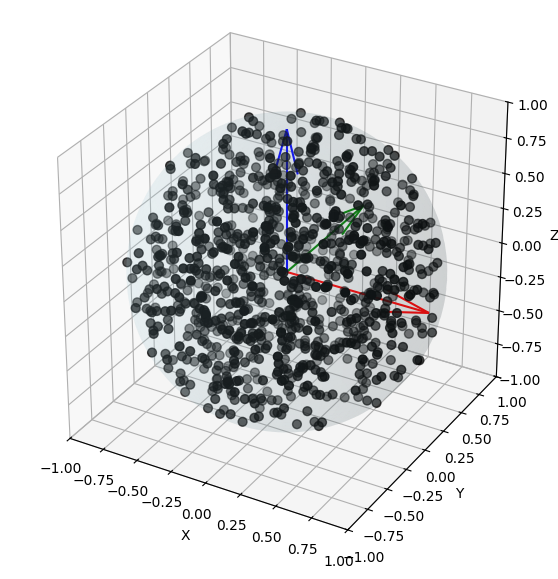

In [5]:
bloch_points_1 = [density_to_bloch(rho) for rho in rho_training]
plot_bloch_sphere(bloch_points_1)

bloch_points_2 = [density_to_bloch(rho) for rho in rho_test]
plot_bloch_sphere(bloch_points_2)

Simulating the evoultion, let's generate the random isometry

In [6]:
#the input is a qubit and the reservoir is a 5-dimensional qudit
dim_in = 2
dim_out = [2, 5]
total_dim_out = np.prod(dim_out) # 10
dim_env = 5

def generate_random_isometry(dim_in, dim_out):
    total_dim_out = np.prod(dim_out)
    #generate a random unitary of size total_dim_out x total_dim_out
    
    U = qt.rand_unitary(total_dim_out)

    #extract the first 2 columns to form the isometry
    #convert to a dense array to slice easily, then back to Qobj
    V_matrix = U.full()[:, :dim_in]

    #qrap it in a Qobj and set the dimensions correctly
    V = qt.Qobj(V_matrix, dims=[dim_out, [dim_in]])

    #check if V.dag() * V results in a 2x2 Identity matrix
    identity_check = V.dag() * V
    A = identity_check.full()
    I = np.eye(dim_in)

    if np.allclose(A,I,atol=1e-8):
        return V


V = generate_random_isometry(dim_in, dim_out)

Generating Random Isometry without Qutip

In [7]:
def random_isometry_via_unitary(d_in=2, d_out=10):
    X = (np.random.randn(d_out, d_out) +
         1j * np.random.randn(d_out, d_out)) / np.sqrt(2)
    Q, R = np.linalg.qr(X)

    diag = np.diag(R)
    phases = diag / np.abs(diag)
    Q = Q * phases

    return Q[:, :d_in]

V2 = random_isometry_via_unitary(2, 10)
print(np.allclose(V2.conj().T @ V2, np.eye(2)))

True


In [8]:
def generate_povm_family(dim, num_elements):
    """
    Generates a list of n POVM elements for a system of dimension 'dim'.
    """
    if num_elements == 1:
        return [qt.qeye(dim)]
    
    #create random positive semidefinite matrices
    raw_elements = []
    for _ in range(num_elements):
        # Using rand_complex_seeded or rand_herm
        seed = qt.rand_herm(dim, density=1.0)
        pos_matrix = seed * seed.dag() 
        raw_elements.append(pos_matrix)
    
    #sum them up to find the normalization factor
    total_sum = sum(raw_elements)
    
    #normalize: M_i = S^{-1/2} G_i S^{-1/2}
    inv_sqrt_sum = total_sum.sqrtm().inv()
    povm = [inv_sqrt_sum * G * inv_sqrt_sum for G in raw_elements]
    
    return povm

Generate a POVM without Qutip

In [9]:
def generate_random_povm(dim, num_elements):
    elements = []
    total_sum = np.zeros((dim, dim), dtype=complex)
    
    for _ in range(num_elements):
        # Generate a random complex matrix
        A = np.random.randn(dim, dim) + 1j * np.random.randn(dim, dim)
        # Make it positive semi-definite (A * A_dagger)
        M = A @ A.conj().T
        elements.append(M)
        total_sum += M
        
    # Normalize so they sum to Identity
    # Use the matrix square root of the inverse sum to normalize
    from scipy.linalg import sqrtm, inv
    normalization = inv(sqrtm(total_sum))
    
    povm = [normalization @ E @ normalization for E in elements]
    return povm

In [10]:
counts = list(range(1, 17))
povm_families = {n: generate_povm_family(5, n) for n in counts}

a = sum(povm_families[5])

print(a)

povm_families2 = {n: generate_random_povm(5,n) for n in counts}
    
c = sum(povm_families2[5])

print(c)

Quantum object: dims=[[5], [5]], shape=(5, 5), type='oper', dtype=Dense, isherm=True
Qobj data =
[[ 1.00000000e+00 -1.08853898e-16 -2.77555756e-17  3.53883589e-16
  -2.42861287e-16]
 [-3.81639165e-17  1.00000000e+00 -7.07767178e-16  5.06539255e-16
  -6.93889390e-16]
 [-1.11022302e-16 -8.18789481e-16  1.00000000e+00 -3.05311332e-16
   1.38777878e-17]
 [ 3.33066907e-16  5.55111512e-17 -1.11022302e-16  1.00000000e+00
   2.56739074e-16]
 [-1.45716772e-16 -7.54604712e-16  2.35922393e-16  4.16333634e-16
   1.00000000e+00]]
[[ 1.00000000e+00+2.76471554e-18j -3.19189120e-16+4.09394740e-16j
   4.44089210e-16-5.30825384e-16j  1.45716772e-16-3.98986399e-17j
   2.14238349e-16-8.95117314e-16j]
 [-1.48318857e-16-1.45716772e-16j  1.00000000e+00+1.39319979e-17j
  -6.24500451e-16-1.52655666e-15j -4.16333634e-17+6.38378239e-16j
  -6.80011603e-16+1.78676518e-16j]
 [ 6.80011603e-16+4.40619763e-16j -5.96744876e-16+1.35308431e-15j
   1.00000000e+00+5.60532523e-17j -5.34294831e-16+2.42861287e-16j
  -1.380839

In [11]:
def compute_finite_stats(rho, povm, shots):
    """
    Computes the estimated probabilities and expectation values
    based on a finite (actually also infinite) number of measurements.
    """
    # if shots = 0, we return the theoretical probabilities without sampling
    if shots == 0:

        probs = [(M @ rho).tr().real for M in povm]

        probs = np.array(probs) / np.sum(probs)

        return probs
    
    else: 
         #calculate theoretical probabilities: p_i = Tr(M_i * rho)
         #we take the real part because Tr is Hermitian but might have tiny imag noise
         probs = [(M @ rho).tr().real for M in povm]
        
         #ensure probabilities sum to 1
         probs = np.array(probs) / np.sum(probs)
        
         #sample from the multinomial distribution
         counts = np.random.multinomial(shots, probs)
        
         #observed frequencies (Finite Statistics)
         observed_probs = counts / shots
        
         return observed_probs
    
def compute_finite_stats2(rho, povm, shots):
    """
    Computes the estimated probabilities and expectation values
    based on a finite (actually also infinite) number of measurements.
    """
    # if shots = 0, we return the theoretical probabilities without sampling
    if shots == 0:

        probs = [(M @ rho).trace().real for M in povm]

        probs = np.array(probs) / np.sum(probs)

        return probs
    
    else: 
         #calculate theoretical probabilities: p_i = Tr(M_i * rho)
         #we take the real part because Tr is Hermitian but might have tiny imag noise
         probs = [(M @ rho).trace().real for M in povm]
        
         #ensure probabilities sum to 1
         probs = np.array(probs) / np.sum(probs)
        
         #sample from the multinomial distribution
         counts = np.random.multinomial(shots, probs)
        
         #observed frequencies (Finite Statistics)
         observed_probs = counts / shots
        
         return observed_probs

# --- Example Usage ---

def generate_random_density_matrix(dim):
    # 1. Create a random complex matrix G
    G = (np.random.randn(dim, dim) + 1j * np.random.randn(dim, dim))
    
    # 2. Compute G * G_dagger (makes it Hermitian and Positive)
    A = G @ G.conj().T
    
    # 3. Normalize the trace to 1
    rho = A / np.trace(A)
    return rho
# Create a random density matrix for C^5
rho = generate_random_density_matrix(5)

# Select the POVM with 10 elements from our previous list
povm_10 = povm_families2[10]

# Simulate 500 shots
est_probs = compute_finite_stats2(rho, povm_10, 0)
print(est_probs)


[0.09845025 0.06931223 0.13717139 0.10708666 0.07688515 0.1091115
 0.07541605 0.0804091  0.11544976 0.13070789]


In [12]:
est_probs = compute_finite_stats2(rho, povm_10, 0)

print(est_probs)

[0.09845025 0.06931223 0.13717139 0.10708666 0.07688515 0.1091115
 0.07541605 0.0804091  0.11544976 0.13070789]


In [13]:
def generate_dataset_probs(rho_list, povm, shots):
    """
    Input: List of qutip density matrices
    Output: A 2D numpy array [num_states x num_povm_elements]
    """
    num_states = len(rho_list)
    num_elements = len(povm)
    prob_matrix = np.zeros((num_states, num_elements))
    
    for idx, rho in enumerate(rho_list):
        # Using the finite statistics logic from before
        rho_qobj = qt.Qobj(rho, dims=[[2], [2]])

        # Evolution and measurement
        rho_qobj_evolved = (V * rho_qobj * V.dag()).ptrace(1)
        est_probs = compute_finite_stats(rho_qobj_evolved, povm, shots=shots)
        prob_matrix[idx, :] = est_probs
        
    return prob_matrix.T


prob_matrix_training = generate_dataset_probs(rho_training, povm_families[10],shots=1000)
print(prob_matrix_training.shape)

(10, 100)


In [27]:
#test to see how partial trace works
rho_a = np.array([[0.5, 0.5],
                  [0.5, 0.5]])

rho_b = np.array([[0, 0],
                  [0, 1]])

# Compute the tensor product
rho_ab = np.kron(rho_a, rho_b)

print("Density Matrix rho_AB:")
print(rho_ab)

def partial_trace(rho, keep_subsystem, dims):
    """
    rho: The joint density matrix
    keep_subsystem: 0 to keep system A, 1 to keep system B
    dims: list of dimensions [dim_A, dim_B]
    """
    # Reshape into a 4D tensor: (dim_A, dim_B, dim_A, dim_B)
    reshaped_rho = rho.reshape(dims + dims)
    
    if keep_subsystem == 0:
        # Trace out B (axis 1 and 3)
        return np.trace(reshaped_rho, axis1=1, axis2=3)
    else:
        # Trace out A (axis 0 and 2)
        return np.trace(reshaped_rho, axis1=0, axis2=2)

# Example: Trace out system B from a 4x4 matrix
# rho_ab = ... (your 4x4 matrix)
# rho_a = partial_trace(rho_ab, keep_subsystem=0, dims=[2, 2])

prova_1 = partial_trace(rho_ab, 0, [2,2])
print(prova_1)

prova_2 = partial_trace(rho_ab, 1, [2,2])
print(prova_2)

Density Matrix rho_AB:
[[0.  0.  0.  0. ]
 [0.  0.5 0.  0.5]
 [0.  0.  0.  0. ]
 [0.  0.5 0.  0.5]]
[[0.5 0.5]
 [0.5 0.5]]
[[0. 0.]
 [0. 1.]]


In [ ]:
prova_3 = V2 @ rho_training[5] @ V2.conj().T



[[ 0.02914812-4.33680869e-18j  0.00134064-4.88648479e-02j
  -0.04712839+4.42028416e-02j -0.03531906+8.22192820e-02j
  -0.00241842+4.06566259e-02j  0.02827959-4.00382672e-03j
  -0.05166388+3.45232197e-02j -0.03466648+2.22738051e-02j
   0.01655668+1.84509880e-02j  0.02113294+4.46027407e-02j]
 [ 0.00134064+4.88648479e-02j  0.09871023+3.46944695e-18j
  -0.08179739-8.67285220e-02j -0.15823882-6.69905806e-02j
  -0.07507123+4.63261675e-03j  0.01315456+5.22642628e-02j
  -0.07164714-9.37855243e-02j -0.03673728-6.66163944e-02j
  -0.03358786+2.91205802e-02j -0.08529398+4.33091314e-02j]
 [-0.04712839-4.42028416e-02j -0.08179739+8.67285220e-02j
   0.15074572+0.00000000e+00j  0.19473542-8.65052681e-02j
   0.06383813-6.82861821e-02j -0.05643265-3.50791459e-02j
   0.14476036+1.87795867e-02j  0.09465605+2.09856178e-02j
   0.00203919-5.71035881e-02j  0.03386827-1.12790501e-01j]
 [-0.03531906-8.22192820e-02j -0.15823882+6.69905806e-02j
   0.19473542+8.65052681e-02j  0.30378605+0.00000000e+00j
   0.120536

In [35]:

def generate_dataset_probs2(rho_list, povm, shots):
    """
    Input: List of qutip density matrices
    Output: A 2D numpy array [num_states x num_povm_elements]
    """
    num_states = len(rho_list)
    num_elements = len(povm)
    prob_matrix = np.zeros((num_states, num_elements))
    
    for idx, rho in enumerate(rho_list):
        # Using the finite statistics logic from before

        # Evolution and measurement
        rho_evolved = partial_trace((V2 @ rho @ V2.conj().T), 1, [2,5])
        est_probs = compute_finite_stats2(rho_evolved, povm, shots=shots)
        prob_matrix[idx, :] = est_probs
        
    return prob_matrix.T


prob_matrix_training2 = generate_dataset_probs2(rho_training, povm_families2[10],shots=1000)
print(prob_matrix_training2.shape)

(10, 100)


In [36]:
w_trained = {}

for n, povm in povm_families.items():
    # Initialize a sub-dictionary for this specific 'n'
    w_trained[n] = {}
    
    # Define the shot counts you want to test
    shot_list = [0, 1000, 10000, 100000, 1000000]
    
    for s in shot_list:
        # Store using the shot count as the key

        pseudo = np.linalg.pinv(generate_dataset_probs(rho_training, povm, s))
        w_trained[n][s] = np.reshape(expe_X_train,(-1,1)).T @ pseudo

print(pseudo.shape)
print(pseudo)
print(w_trained[10][1000].shape)
print(w_trained[10][1000])


(100, 16)
[[-14.61402057  32.62903448  35.04941227 ...   1.25024579  24.98810651
  -32.61475564]
 [ 10.80291049  -7.97867911  32.66249988 ... -41.87923526 -67.98665432
   99.29604789]
 [-44.18381783   2.18127372  23.05717794 ...  44.59745421   3.5670958
    9.92993069]
 ...
 [-59.7076362   13.70461131  -1.34935285 ...  67.13502454  29.31762869
   65.48069623]
 [-35.44514611  -6.16593483  26.48408849 ...  29.64352339 -36.27954288
   68.37249804]
 [-45.93707981  -1.35918297  38.29262071 ...  45.54354538  43.81399948
  -48.52430999]]
(1, 10)
[[-13.75842163  -0.33750815   2.1741722    2.72495392  -0.75462377
    4.21950282   5.0453449   -1.32521965  -2.1413011    0.38066603]]


In [17]:
test_prob = {}

for n, povm in povm_families.items():

    test_prob[n] = {}

    shot_list = [0, 1000, 10000, 100000, 1000000]

    for s in shot_list:
        test_prob[n][s] = generate_dataset_probs(rho_test, povm, s)

In [18]:
MSE_Ntrain_infty = {}
for n in povm_families.keys():
    MSE_Ntrain_infty[n] = {}

    shot_list = [1000, 10000, 100000, 1000000]

    for s in shot_list:
        w = w_trained[n][0]
        est_expe_X = w @ test_prob[n][s]
        MSE_Ntrain_infty[n][s] = np.mean((est_expe_X - np.reshape(expe_X_test, (-1,1)).T)**2)

In [19]:
n_values = sorted(MSE_Ntrain_infty.keys())
shot_values = sorted(MSE_Ntrain_infty[n_values[0]].keys())

<>:8: SyntaxWarning: invalid escape sequence '\i'
<>:16: SyntaxWarning: invalid escape sequence '\i'
<>:8: SyntaxWarning: invalid escape sequence '\i'
<>:16: SyntaxWarning: invalid escape sequence '\i'
/var/folders/3k/fd7stp7s1rsch3ck5w1hhcd80000gn/T/ipykernel_9110/2993245897.py:8: SyntaxWarning: invalid escape sequence '\i'
  label = f"Shots: {s}" if s > 0 else "Exact ($s=\infty$)"
/var/folders/3k/fd7stp7s1rsch3ck5w1hhcd80000gn/T/ipykernel_9110/2993245897.py:16: SyntaxWarning: invalid escape sequence '\i'
  plt.title('MSE($\infty$, Ntest)')


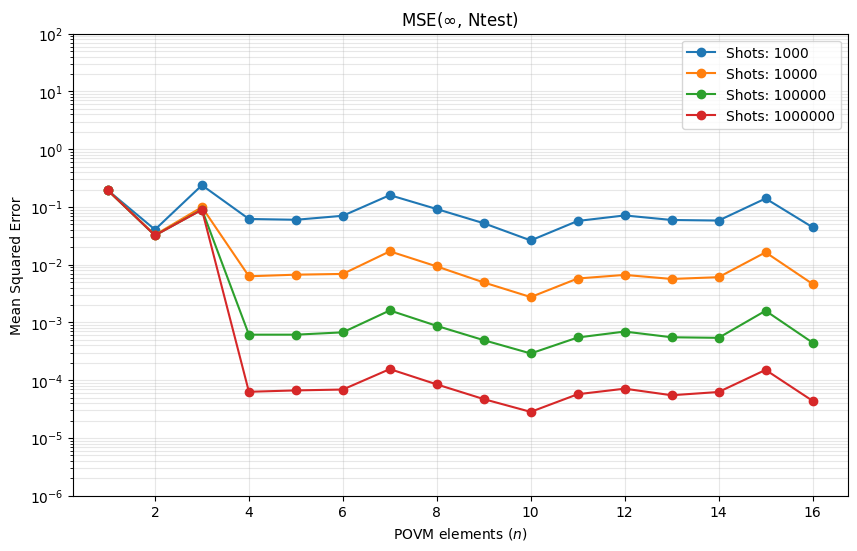

In [20]:
plt.figure(figsize=(10, 6))

# 2. Loop through shots to create one line per 's'
for s in shot_values:
    # Extract MSE for this specific 's' across all 'n'
    y_values = [MSE_Ntrain_infty[n][s] for n in n_values]
    
    label = f"Shots: {s}" if s > 0 else "Exact ($s=\infty$)"
    plt.plot(n_values, y_values, marker='o', linestyle='-', label=label)

# 3. Formatting
plt.yscale('log') # Usually necessary for MSE to see the scale of improvement
plt.xlabel('POVM elements ($n$)')
plt.ylim(1e-6, 1e2)
plt.ylabel('Mean Squared Error')
plt.title('MSE($\infty$, Ntest)')
plt.grid(True, which="both", alpha=0.3)
plt.legend()
plt.show()


<>:22: SyntaxWarning: invalid escape sequence '\i'
<>:30: SyntaxWarning: invalid escape sequence '\i'
<>:22: SyntaxWarning: invalid escape sequence '\i'
<>:30: SyntaxWarning: invalid escape sequence '\i'
/var/folders/3k/fd7stp7s1rsch3ck5w1hhcd80000gn/T/ipykernel_9110/980110361.py:22: SyntaxWarning: invalid escape sequence '\i'
  label = f"Shots: {s}" if s > 0 else "Exact ($s=\infty$)"
/var/folders/3k/fd7stp7s1rsch3ck5w1hhcd80000gn/T/ipykernel_9110/980110361.py:30: SyntaxWarning: invalid escape sequence '\i'
  plt.title('MSE (Ntrain, $\infty$)')


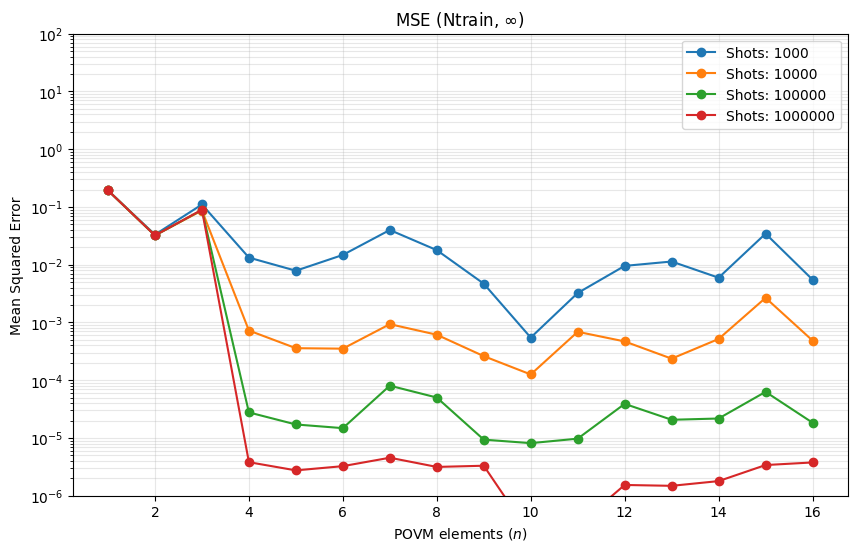

In [21]:
MSE_Ntest_infty = {}
for n in povm_families.keys():
    MSE_Ntest_infty[n] = {}

    shot_list = [1000, 10000, 100000, 1000000]

    for s in shot_list:
        w = w_trained[n][s]
        est_expe_X = w @ test_prob[n][0]
        MSE_Ntest_infty[n][s] = np.mean((est_expe_X - np.reshape(expe_X_test, (-1,1)).T)**2)

n_values = sorted(MSE_Ntest_infty.keys())
shot_values = sorted(MSE_Ntest_infty[n_values[0]].keys())

plt.figure(figsize=(10, 6))

# 2. Loop through shots to create one line per 's'
for s in shot_values:
    # Extract MSE for this specific 's' across all 'n'
    y_values = [MSE_Ntest_infty[n][s] for n in n_values]
    
    label = f"Shots: {s}" if s > 0 else "Exact ($s=\infty$)"
    plt.plot(n_values, y_values, marker='o', linestyle='-', label=label)

# 3. Formatting
plt.yscale('log') # Usually necessary for MSE to see the scale of improvement
plt.xlabel('POVM elements ($n$)')
plt.ylim(1e-6, 1e2)
plt.ylabel('Mean Squared Error')
plt.title('MSE (Ntrain, $\infty$)')
plt.grid(True, which="both", alpha=0.3)
plt.legend()
plt.show()

<>:22: SyntaxWarning: invalid escape sequence '\i'
<>:22: SyntaxWarning: invalid escape sequence '\i'
/var/folders/3k/fd7stp7s1rsch3ck5w1hhcd80000gn/T/ipykernel_9110/4184857076.py:22: SyntaxWarning: invalid escape sequence '\i'
  label = f"Shots: {s}" if s > 0 else "Exact ($s=\infty$)"


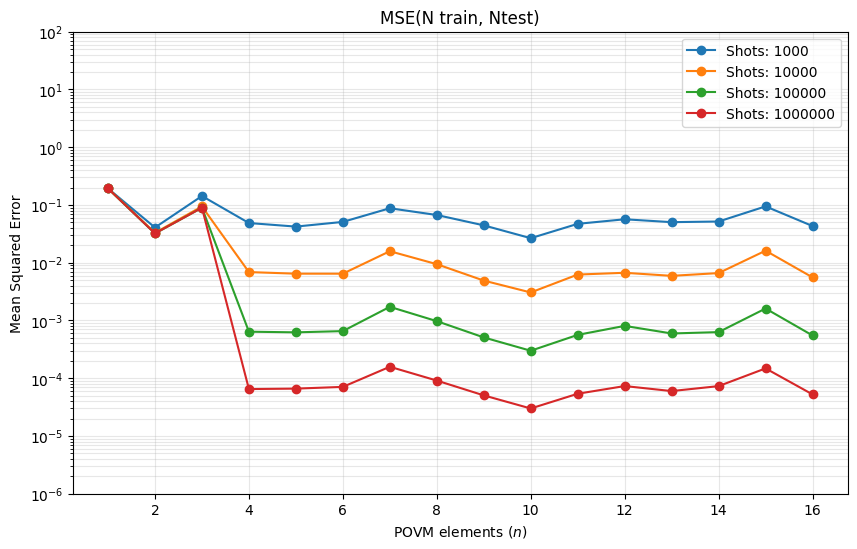

In [22]:
MSE_finite = {}
for n in povm_families.keys():
    MSE_finite[n] = {}

    shot_list = [1000, 10000, 100000, 1000000]

    for s in shot_list:
        w = w_trained[n][s]
        est_expe_X = w @ test_prob[n][s]
        MSE_finite[n][s] = np.mean((est_expe_X - np.reshape(expe_X_test, (-1,1)).T)**2)

n_values = sorted(MSE_finite.keys())
shot_values = sorted(MSE_finite[n_values[0]].keys())

plt.figure(figsize=(10, 6))

# 2. Loop through shots to create one line per 's'
for s in shot_values:
    # Extract MSE for this specific 's' across all 'n'
    y_values = [MSE_finite[n][s] for n in n_values]
    
    label = f"Shots: {s}" if s > 0 else "Exact ($s=\infty$)"
    plt.plot(n_values, y_values, marker='o', linestyle='-', label=label)

# 3. Formatting
plt.yscale('log') # Usually necessary for MSE to see the scale of improvement
plt.xlabel('POVM elements ($n$)')
plt.ylim(1e-6, 1e2)
plt.ylabel('Mean Squared Error')
plt.title('MSE(N train, Ntest)')
plt.grid(True, which="both", alpha=0.3)
plt.legend()
plt.show()

In [23]:
train_prob = {}
k = {}

for n, povm in povm_families.items():

    train_prob[n] = {}
    k[n] = {}

    shot_list = [0, 1000, 10000, 100000, 1000000]

    for s in shot_list:
        train_prob[n][s] = generate_dataset_probs(rho_training, povm, s)

        singular_values = np.linalg.svd(train_prob[n][s], compute_uv=False)

        k[n][s] = np.max(singular_values)/np.min(singular_values)



<>:9: SyntaxWarning: invalid escape sequence '\i'
<>:17: SyntaxWarning: invalid escape sequence '\i'
<>:9: SyntaxWarning: invalid escape sequence '\i'
<>:17: SyntaxWarning: invalid escape sequence '\i'
/var/folders/3k/fd7stp7s1rsch3ck5w1hhcd80000gn/T/ipykernel_9110/260059056.py:9: SyntaxWarning: invalid escape sequence '\i'
  label = f"Shots: {s}" if s > 0 else "Exact ($s=\infty$)"
/var/folders/3k/fd7stp7s1rsch3ck5w1hhcd80000gn/T/ipykernel_9110/260059056.py:17: SyntaxWarning: invalid escape sequence '\i'
  plt.title('MSE($\infty$, Ntest)')


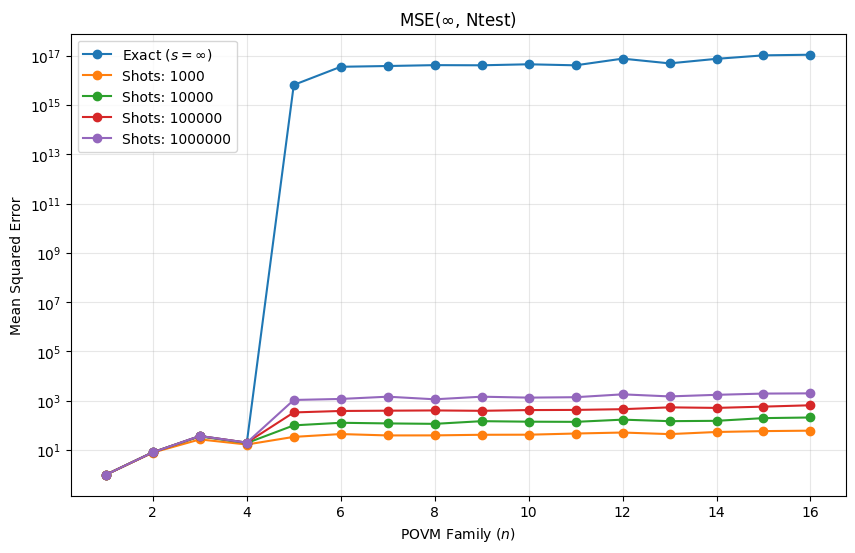

In [24]:
shot_values = sorted(k[n_values[0]].keys())
plt.figure(figsize=(10, 6))

# 2. Loop through shots to create one line per 's'
for s in shot_values:
    # Extract MSE for this specific 's' across all 'n'
    y_values = [k[n][s] for n in n_values]
    
    label = f"Shots: {s}" if s > 0 else "Exact ($s=\infty$)"
    plt.plot(n_values, y_values, marker='o', linestyle='-', label=label)

# 3. Formatting
plt.yscale('log') # Usually necessary for MSE to see the scale of improvement
plt.xlabel('POVM Family ($n$)')

plt.ylabel('Mean Squared Error')
plt.title('MSE($\infty$, Ntest)')
plt.grid(True, which="both", alpha=0.3)
plt.legend()
plt.show()